In [3]:
! pip install git+https://www.github.com/djpasseyjr/interfere.git@5d000e5d1715e91000b029c753a75e04586dda1b
! pip install git+https://www.github.com/djpasseyjr/interfere_experiments.git@7ad3b124eb5082d60dd74316446aa2e7794baee0
! pip install optuna

  Cloning https://www.github.com/djpasseyjr/interfere.git (to revision 5d000e5d1715e91000b029c753a75e04586dda1b) to /tmp/pip-req-build-6kezv86m
  Running command git clone --filter=blob:none --quiet https://www.github.com/djpasseyjr/interfere.git /tmp/pip-req-build-6kezv86m
  Running command git rev-parse -q --verify 'sha^5d000e5d1715e91000b029c753a75e04586dda1b'
  Running command git fetch -q https://www.github.com/djpasseyjr/interfere.git 5d000e5d1715e91000b029c753a75e04586dda1b
  Running command git checkout -q 5d000e5d1715e91000b029c753a75e04586dda1b
  Resolved https://www.github.com/djpasseyjr/interfere.git to commit 5d000e5d1715e91000b029c753a75e04586dda1b
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Cloning https://github.com/djpasseyjr/pyclustering to /tmp/pip-install-i0fbqk_2/pyclustering_1036e958d9974646a7ce2868d7385cff
  Running command git clone --filter=blob:none --quiet https://git

In [2]:
import pickle as pkl
import traceback
import warnings
warnings.filterwarnings('ignore')


import interfere
import interfere_experiments as ie
from interfere_experiments.quick_models import gut_check_coupled_logistic, gut_check_belozyorov
import matplotlib.pyplot as plt
import numpy as np
import optuna

# from google.colab import drive
# drive.mount('/content/drive', force_remount=True)


SAVE_DIR = "" # "drive/MyDrive/Docs/PhD Research/DissertationColabs/"
GUT_CHECK_PARAMS = pkl.load(open(SAVE_DIR + 'gut_check_params.pkl', 'rb'))
SEED = 11
RNG = np.random.default_rng(SEED)
METHODS = [
    # interfere.methods.LTSFLinearForecaster,
    # interfere.methods.VAR,
    # interfere.methods.LSTM,
    # interfere.methods.NHITS,
    # interfere.methods.ResComp,
    interfere.methods.SINDY,
]
MODEL_NAMES = model_names = ["cml", "belozy"]


In [3]:
# @title Create CML Training Data

dim = 10
dt = 1
window = 10
num_train_obs=350

cml_train_prior_states = RNG.random((window, dim))
cml_train_prior_t = np.arange(-window * dt + 1, 1, dt)
cml_train_t = np.arange(0, num_train_obs * dt, dt)

# Simulate training data.
cml_train_states = gut_check_coupled_logistic().simulate(
    cml_train_t, prior_states=cml_train_prior_states, prior_t=cml_train_prior_t)

In [4]:
# @title Create Belozyorov Training Data

dim = 3
dt = 0.05
window = 10
num_train_obs=350

belozy_train_prior_states = RNG.random((window, dim))
belozy_train_prior_t = np.arange((-window + 1) * dt, 1 * dt, dt)
belozy_train_prior_t[-1] = 0
belozy_train_t = np.arange(0, num_train_obs * dt, dt)

# Simulate training data.
belozy_train_states = gut_check_belozyorov().simulate(
    belozy_train_t, prior_states=belozy_train_prior_states, prior_t=belozy_train_prior_t)

In [8]:
params = GUT_CHECK_PARAMS[method_type.__name__]["cml"]["forecast_rmse"]
params

{'optimizer__threshold': 2.619572195011037,
 'optimizer__alpha': 0.0001587441595198887,
 'discrete_time': True,
 'feature_library': PolynomialLibrary(),
 'differentiation_method': SINDyDerivative(alpha=0.01, kind='trend_filtered', order=1)}

In [5]:
# @title Fit Methods and Create GenerativeForecasters.

cml_gen_fcast = []

for method_type in METHODS:
    params = GUT_CHECK_PARAMS[method_type.__name__]["cml"]["forecast_rmse"]
    method = method_type(**params)
    method.fit(cml_train_t, cml_train_states)
    gen_forecaster = interfere.dynamics.GenerativeForecaster(method)
    cml_gen_fcast.append(
        gen_forecaster
    )

belozy_gen_fcast= []

for method_type in METHODS:
    params = GUT_CHECK_PARAMS[method_type.__name__]["belozy"]["forecast_rmse"]
    method = method_type(**params)
    method.fit(belozy_train_t, belozy_train_states)
    belozy_gen_fcast.append(
        interfere.dynamics.GenerativeForecaster(method)
    )


x shape does not match training shape


Traceback (most recent call last):
  File "/var/folders/s1/lzq1k08d2572hqgdq0r3j1qm0000gn/T/ipykernel_32720/764023333.py", line 3, in <module>
    X = gen_forecaster.simulate(
  File "/Users/djpassey/Code/interfere/interfere/base.py", line 137, in simulate
    return self._simulate(
  File "/Users/djpassey/Code/interfere/interfere/dynamics/generative_forecasters.py", line 88, in _simulate
    new_states = self.fitted_method.predict(
  File "/Users/djpassey/Code/interfere/interfere/methods/base.py", line 396, in predict
    endog_pred = self._predict(
  File "/Users/djpassey/Code/interfere/interfere/methods/sindy.py", line 98, in _predict
    endog_pred = self.sindy.simulate(
  File "/Users/djpassey/Code/interfere/venv_interfere/lib/python3.9/site-packages/pysindy/pysindy.py", line 836, in simulate
    x[i] = self.predict(x[i - 1 : i])
  File "/Users/djpassey/Code/interfere/venv_interfere/lib/python3.9/site-packages/pysindy/pysindy.py", line 477, in predict
    result = [self.model.pred

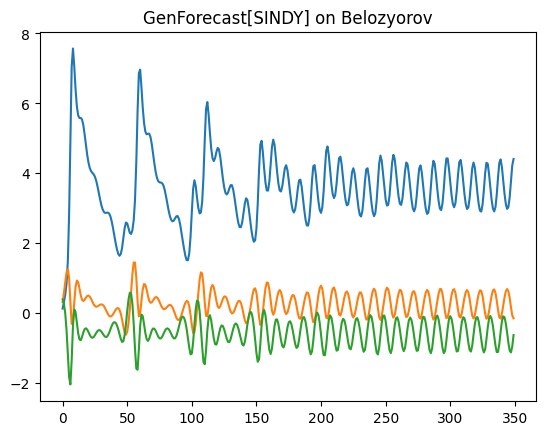

In [6]:
for gen_forecaster in cml_gen_fcast:
    try:
        X = gen_forecaster.simulate(
            cml_train_t, cml_train_prior_states, prior_t=cml_train_prior_t)
        plt.plot(X)
        plt.title(f"GenForecast[{type(gen_forecaster.fitted_method).__name__}] on CML")
        plt.show()
    except Exception as e:
        print(e)
        # Print stack trace
        traceback.print_exc()

for gen_forecaster in belozy_gen_fcast:
    try:
        X = gen_forecaster.simulate(
            belozy_train_t, belozy_train_prior_states, prior_t=belozy_train_prior_t)
        plt.plot(X)
        plt.title(f"GenForecast[{type(gen_forecaster.fitted_method).__name__}] on Belozyorov")
        plt.show()
    except Exception as e:
        print(e)
        # Print stack trace
        traceback.print_exc()

In [6]:
studies = []
objectives = []

for gen_forecaster in cml_gen_fcast:
    for method in METHODS:
        objective = ie.control_vs_resp.CVROptunaObjective(
            model=gen_forecaster,
            method_type=method,
            num_train_obs=150,
            num_forecast_obs=50,
            timestep=1.0,
            intervention=interfere.PerfectIntervention(0, 0.2),
            train_prior_states=cml_train_prior_states
        )
        study = optuna.create_study(directions=objective.metric_directions)
        study.optimize(objective, n_trials=25)
        studies.append(study)
        objectives.append(objective)
        pkl.dump(
            {"studies": studies, "objectives": objectives},
            open(SAVE_DIR + 'generative_forecaster_studies.pkl', 'wb')
        )


[I 2024-09-20 13:01:11,983] A new study created in memory with name: no-name-a4c8590b-72a1-4fe0-b3a1-4c339e343292
[I 2024-09-20 13:01:18,010] Trial 0 finished with values: [6.0, 1.193190828266388, 1.0, 50.0, 0.7802230562459469, 1.0, 50.0, 0.8105910507741443, 1.0] and parameters: {'seq_len': 12, 'lr': 0.003036993395605772, 'pred_len': 11, 'num_epochs': 50}. 
[I 2024-09-20 13:01:23,583] Trial 1 finished with values: [1.0, 1.2869842195475658, 0.7, 50.0, 1.0413751293778442, 1.0, 50.0, 0.7650478206333449, 1.0] and parameters: {'seq_len': 7, 'lr': 0.09482892391337644, 'pred_len': 8, 'num_epochs': 50}. 
[I 2024-09-20 13:01:36,836] Trial 2 finished with values: [2.0, 9.56081729635892, 0.0, 15.0, 65.5205741332477, 0.0, 50.0, 21.990322721914712, 0.0] and parameters: {'seq_len': 14, 'lr': 1.3099273712678353e-05, 'pred_len': 23, 'num_epochs': 300}. 
[I 2024-09-20 13:01:44,681] Trial 3 finished with values: [1.0, 12.171603344259282, 0.0, 1.0, 103.94265200093939, 0.0, 2.0, 98.48762860559556, 0.0] an

 lsoda--  at t (=r1), too much accuracy requested    
       for precision of machine..  see tolsf (=r2)   
      in above,  r1 =  0.1500000000000D+03   r2 =                  NaN


[I 2024-09-20 16:54:42,135] Trial 11 finished with values: [150.0, 1.7642848433179286, 0.0, 50.0, 3.6979479302222766, 1.0, 0.0, 127682016146.96225, 1.0] and parameters: {'gamma': 314.468990600399, 'sigma': 48.22969512940982, 'delta': 27.923912149747768, 'mean_degree': 0.4329460062921531, 'res_sz': 74, 'window': 17.79163280321201, 'spect_rad': 1.284195480609124, 'ridge_alpha': 14.40235457875187}. 
[I 2024-09-20 16:54:49,142] Trial 12 finished with values: [1.0, 4.359567347187239, 0.1, 50.0, 6.54464998943618, 0.4, 50.0, 7.073590625975441, 0.2222222222222222] and parameters: {'gamma': 128.07414354295454, 'sigma': 43.46736102888557, 'delta': 7.32868496273558, 'mean_degree': 4.39444380017257, 'res_sz': 15, 'window': 0.1872563516237157, 'spect_rad': 0.056500285068044845, 'ridge_alpha': 4.7430734827641376e-08}. 
[I 2024-09-20 16:55:00,624] Trial 13 finished with values: [1.0, 3.8390698207062677, 0.0, 50.0, 6.169607987946851, 0.6, 1.0, 33.556342614603984, 0.7777777777777778] and parameters: {'

 lsoda--  at t (=r1), too much accuracy requested    
       for precision of machine..  see tolsf (=r2)   
      in above,  r1 =  0.1500000000000D+03   r2 =                  NaN
 lsoda--  at t (=r1), too much accuracy requested    
       for precision of machine..  see tolsf (=r2)   
      in above,  r1 =  0.1000000000000D+01   r2 =                  NaN
 lsoda--  at t (=r1), too much accuracy requested    
       for precision of machine..  see tolsf (=r2)   
      in above,  r1 =  0.1500000000000D+03   r2 =                  NaN


[I 2024-09-20 16:55:11,672] Trial 15 finished with values: [0.0, 17280626356.193798, 0.0, 0.0, 131542665527.77473, 1.0, 0.0, 127682016146.96225, 1.0] and parameters: {'gamma': 399.4617226637572, 'sigma': 19.343543692750554, 'delta': 7.659975468078983, 'mean_degree': 1.284582037364494, 'res_sz': 19, 'window': 11.955584398662772, 'spect_rad': 0.04646420935782883, 'ridge_alpha': 3.8582740974182356e-06}. 
[I 2024-09-20 16:55:15,625] Trial 16 finished with values: [150.0, 1.6189369219207568, 0.7, 50.0, 8.109167159519966, 0.3, 50.0, 8.087445400543318, 0.0] and parameters: {'gamma': 199.85478660046755, 'sigma': 21.679706984571563, 'delta': 16.528608313331265, 'mean_degree': 1.3447415482429343, 'res_sz': 12, 'window': 1.8349024087335808, 'spect_rad': 0.00253563179683822, 'ridge_alpha': 0.32195950899276854}. 
[I 2024-09-20 16:55:20,112] Trial 17 finished with values: [1.0, 1371.7827802688262, 1.0, 50.0, 2.1951626850390946, 1.0, 0.0, 72227855562.53247, 1.0] and parameters: {'gamma': 9.7000643315

...

 lsoda--  at t (=r1), too much accuracy requested    
       for precision of machine..  see tolsf (=r2)   
      in above,  r1 =  0.1500000000000D+03   r2 =                  NaN
 lsoda--  at t (=r1), too much accuracy requested    
       for precision of machine..  see tolsf (=r2)   
      in above,  r1 =  0.1000000000000D+01   r2 =                  NaN


[I 2024-09-20 23:27:45,392] Trial 0 finished with values: [0.0, 4526074037.0116005, 0.0, 0.0, 4554639876.305029, 0.0, 0.0, 642680613.7713463, 1.0] and parameters: {'gamma': 424.3814465466991, 'sigma': 24.751870018194964, 'delta': 69.9811344334518, 'mean_degree': 1.1883954830767904, 'res_sz': 33, 'window': 4.2250714376837895, 'spect_rad': 78.37650284370858, 'ridge_alpha': 0.018924341973247643}. 
[I 2024-09-20 23:27:54,193] Trial 1 finished with values: [1.0, 1.3682591818766243, 0.2, 50.0, 1.21864020134567, 0.0, 50.0, 1.2319752830780006, 0.0] and parameters: {'gamma': 216.91578482037215, 'sigma': 77.06527420848167, 'delta': 4.732177464111847, 'mean_degree': 1.4699256641453868, 'res_sz': 13, 'window': 0.33177359688320596, 'spect_rad': 11.463433875130079, 'ridge_alpha': 0.28053409985500405}. 
[I 2024-09-20 23:28:01,412] Trial 2 finished with values: [2.0, 20899.751712038484, 1.0, 2.0, 3.086863670840552, 0.0, 0.0, 3.099991895050874, 0.0] and parameters: {'gamma': 213.05837200126138, 'sigma'

 lsoda--  at t (=r1), too much accuracy requested    
       for precision of machine..  see tolsf (=r2)   
      in above,  r1 =  0.1500000000000D+03   r2 =                  NaN


[I 2024-09-20 23:29:14,485] Trial 16 finished with values: [150.0, 0.8793096170323861, 0.6, 50.0, 0.8747389698272958, 0.6, 0.0, 4544438201.519387, 0.0] and parameters: {'gamma': 379.17788704374846, 'sigma': 71.4801345341606, 'delta': 25.048950835655653, 'mean_degree': 4.0819047501635595, 'res_sz': 98, 'window': 40.42203915126225, 'spect_rad': 0.03395985867664975, 'ridge_alpha': 49.124684746523776}. 
[I 2024-09-20 23:29:23,963] Trial 17 finished with values: [1.0, 1.3279986319018149, 0.0, 50.0, 1.001551281533305, 0.4, 1.0, 1.442341639641189, 0.0] and parameters: {'gamma': 126.00161052218812, 'sigma': 37.1883622093525, 'delta': 82.39501041763856, 'mean_degree': 4.0099267058777555, 'res_sz': 37, 'window': 0.00853111743000945, 'spect_rad': 0.013896647926122087, 'ridge_alpha': 10.454424123063808}. 
[I 2024-09-20 23:47:30,324] Trial 18 finished with values: [1.0, 1.3877421165198656, 0.2, 50.0, 1.2228783233870164, 0.0, 0.0, 390.79582642065145, 0.0] and parameters: {'gamma': 40.47283689615059,

OSError: [Errno 28] No space left on device